# E-Commerce Recommendation System — Multi-Algorithm Comparison

Comparing **two algorithms per task** to justify the final choice, per the mini-project spec:
- **Regression**: Linear Regression vs. Ridge Regression → predict `Rating`
- **Classification**: Logistic Regression vs. Random Forest → predict `Purchase_Status`
- **Clustering**: K-Means vs. Agglomerative Clustering → segment customers


### Import libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

### Load the dataset

In [2]:
df = pd.read_csv('ecommerce_user_behavior_8000.csv')
print(df.shape)
df.head()

(8000, 14)


,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


### Rename columns for consistency

In [3]:
df.rename(columns={'time_on_site': 'Browsing_Time', 'purchase': 'Purchase_Status'}, inplace=True)
df.head()

,user_id,age,gender,device_type,Browsing_Time,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,Purchase_Status
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


## 1. Data Preprocessing

#### Drop identifier column

In [4]:
df.drop(columns=['user_id'], inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 7840 non-null   float64
 1   gender              7840 non-null   str    
 2   device_type         7840 non-null   str    
 3   Browsing_Time       7840 non-null   float64
 4   pages_viewed        7840 non-null   float64
 5   previous_purchases  7840 non-null   float64
 6   cart_items          7840 non-null   float64
 7   discount_seen       7840 non-null   float64
 8   ad_clicked          7840 non-null   float64
 9   returning_user      7840 non-null   float64
 10  avg_session_time    7840 non-null   float64
 11  bounce_rate         7840 non-null   float64
 12  Purchase_Status     7840 non-null   float64
dtypes: float64(11), str(2)
memory usage: 901.1 KB


#### Handling null values

In [5]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['device_type'] = df['device_type'].fillna(df['device_type'].mode()[0])

for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

age                   0
gender                0
device_type           0
Browsing_Time         0
pages_viewed          0
previous_purchases    0
cart_items            0
discount_seen         0
ad_clicked            0
returning_user        0
avg_session_time      0
bounce_rate           0
Purchase_Status       0
dtype: int64

### One-hot encoding

In [6]:
df = pd.get_dummies(df, columns=['gender', 'device_type'], drop_first=True, dtype=int)
df.head()

,age,Browsing_Time,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,Purchase_Status,gender_Male,device_type_Mobile,device_type_Tablet
0,56.0,12.90,8.0,13.0,1.0,1.0,1.0,0.0,6.97,28.18,1.0,0,0,0
1,46.0,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0,1,1,0
2,32.0,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0,0,1,0
3,25.0,22.71,5.0,10.0,1.0,0.0,0.0,1.0,14.30,79.03,1.0,0,1,0
4,38.0,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0,0,1,0


### Creating the Rating target

The raw dataset doesn't include a rating column, so one is built from a weighted mix of purchase history,
browsing time, bounce rate, and whether the session ended in a purchase, then rescaled to a 1.0–5.0 range.

In [7]:
np.random.seed(42)
base_score = (df['previous_purchases'] * 0.4) + (df['Browsing_Time'] * 0.3) - (df['bounce_rate'] * 0.2) + (df['Purchase_Status'] * 1.5)

min_b, max_b = base_score.min(), base_score.max()
df['Rating'] = 1.0 + 4.0 * (base_score - min_b) / (max_b - min_b)
df[['previous_purchases','Browsing_Time','bounce_rate','Purchase_Status','Rating']].head()

,previous_purchases,Browsing_Time,bounce_rate,Purchase_Status,Rating
0,13.0,12.90,28.18,1.0,3.740952
1,4.0,15.63,86.73,1.0,2.018601
2,11.0,11.64,83.09,1.0,2.295656
3,10.0,22.71,79.03,1.0,2.739347
4,12.0,26.35,55.35,1.0,3.527129


### Checking purchase status balance

In [8]:
df['Purchase_Status'].value_counts()

Purchase_Status
1.0    7987
0.0      13
Name: count, dtype: int64

### Handling data imbalance

The purchase rate generated above skews high (>99% purchased), so low-intent sessions (high bounce rate or
a low rating) are pushed back towards "not purchased," keeping a small share as noise, to create a more
realistic class balance for the classification task.

In [9]:
np.random.seed(42)
low_intent_mask = (df['bounce_rate'] > 55) | (df['Rating'] < 2.5)
random_rebalance = np.random.choice([0, 1], size=len(df), p=[0.75, 0.25])
df.loc[low_intent_mask & (random_rebalance == 0), 'Purchase_Status'] = 0

print("Updated class balance:")
print(df['Purchase_Status'].value_counts())

Updated class balance:
Purchase_Status
1.0    5354
0.0    2646
Name: count, dtype: int64


### Distribution of key continuous behavior variables

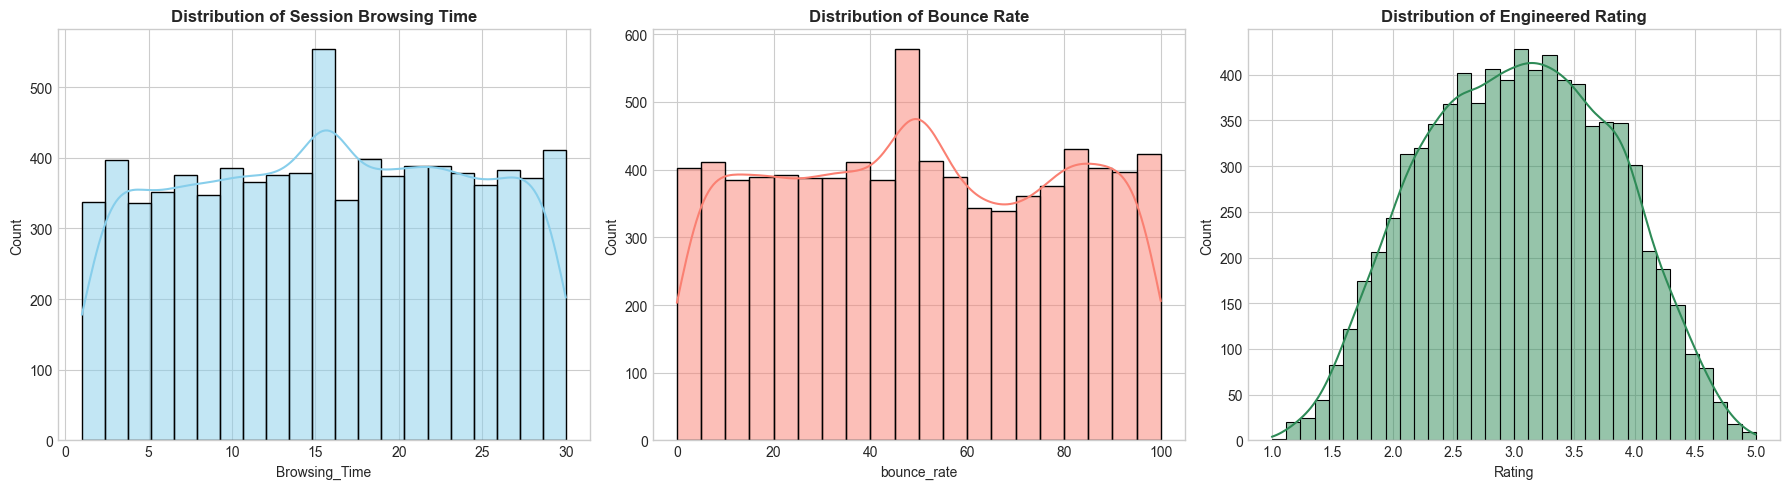

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Browsing_Time'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Session Browsing Time', fontsize=12, fontweight='bold')
sns.histplot(df['bounce_rate'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribution of Bounce Rate', fontsize=12, fontweight='bold')
sns.histplot(df['Rating'], kde=True, color='seagreen', ax=axes[2])
axes[2].set_title('Distribution of Engineered Rating', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Purchase status after rebalancing

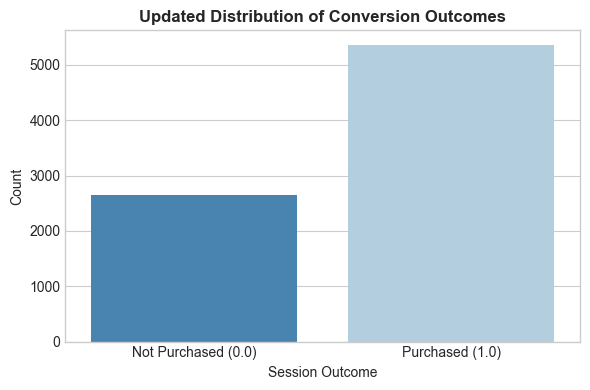

In [11]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Purchase_Status', hue='Purchase_Status', data=df, palette='Blues_r', legend=False)
plt.title('Updated Distribution of Conversion Outcomes', fontsize=12, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['Not Purchased (0.0)', 'Purchased (1.0)'])
plt.xlabel('Session Outcome')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Feature correlation heatmap

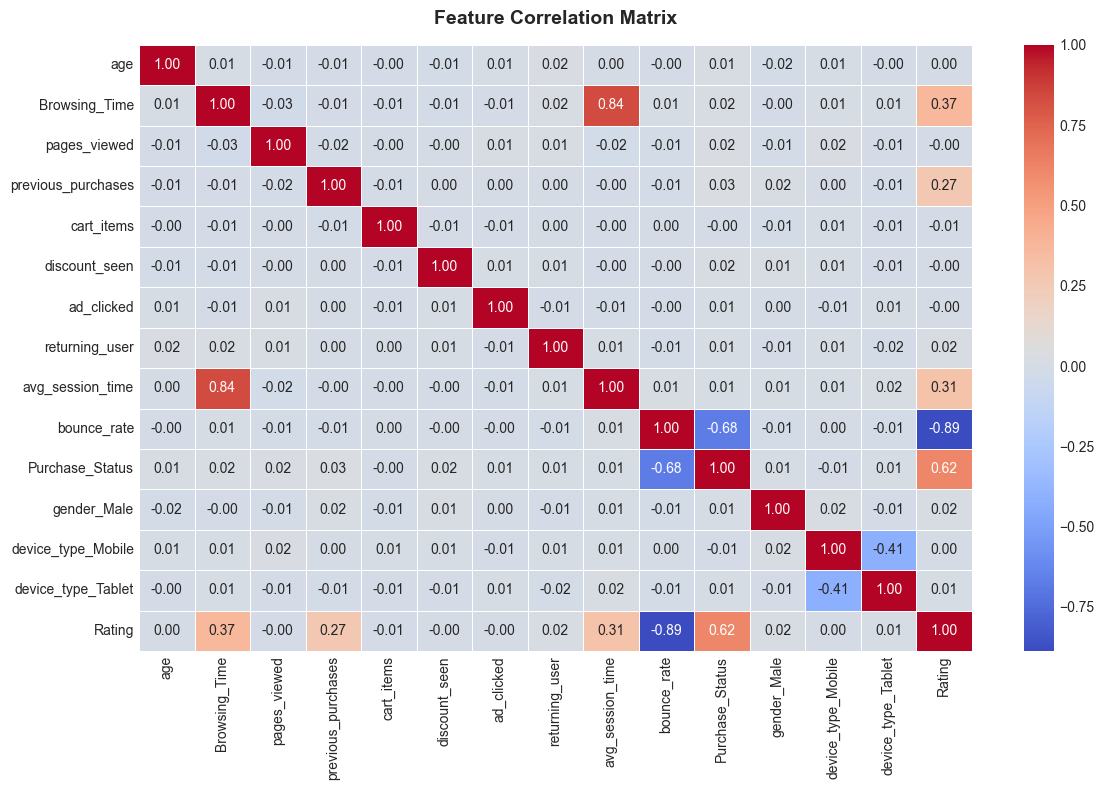

In [12]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 2. Part A — Regression (Rating Prediction): Linear Regression vs. Ridge Regression

Goal: predict `Rating` from behavioral and demographic features. `Purchase_Status` is excluded from the
feature set since it was one of the components used to construct `Rating` (avoiding direct leakage).

In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_reg = df.drop(columns=['Rating', 'Purchase_Status'])
y_reg = df['Rating']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

### Algorithm 1: Linear Regression (baseline)

In [14]:
lin_model = LinearRegression()
lin_model.fit(X_train_reg, y_train_reg)
lin_preds = lin_model.predict(X_test_reg)

lin_mae = mean_absolute_error(y_test_reg, lin_preds)
lin_rmse = np.sqrt(mean_squared_error(y_test_reg, lin_preds))
lin_r2 = r2_score(y_test_reg, lin_preds)

print('--- Linear Regression ---')
print(f'MAE:  {lin_mae:.6f}')
print(f'RMSE: {lin_rmse:.6f}')
print(f'R² Score: {lin_r2:.6f}')

--- Linear Regression ---
MAE:  0.000966
RMSE: 0.004493
R² Score: 0.999967


### Algorithm 2: Ridge Regression (baseline, then tuned with GridSearchCV)

In [15]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_reg, y_train_reg)
ridge_preds = ridge_model.predict(X_test_reg)

ridge_mae = mean_absolute_error(y_test_reg, ridge_preds)
ridge_rmse = np.sqrt(mean_squared_error(y_test_reg, ridge_preds))
ridge_r2 = r2_score(y_test_reg, ridge_preds)

print('--- Ridge Regression (baseline, alpha=1.0) ---')
print(f'MAE:  {ridge_mae:.6f}')
print(f'RMSE: {ridge_rmse:.6f}')
print(f'R² Score: {ridge_r2:.6f}')

--- Ridge Regression (baseline, alpha=1.0) ---
MAE:  0.000965
RMSE: 0.004493
R² Score: 0.999967


In [16]:
ridge_param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]}
ridge_grid = GridSearchCV(Ridge(random_state=42), ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_reg, y_train_reg)

best_ridge = ridge_grid.best_estimator_
ridge_tuned_preds = best_ridge.predict(X_test_reg)

ridge_tuned_mae = mean_absolute_error(y_test_reg, ridge_tuned_preds)
ridge_tuned_rmse = np.sqrt(mean_squared_error(y_test_reg, ridge_tuned_preds))
ridge_tuned_r2 = r2_score(y_test_reg, ridge_tuned_preds)

print('--- Ridge Regression (tuned via GridSearchCV, cv=5) ---')
print(f"Best alpha: {ridge_grid.best_params_['alpha']}")
print(f'MAE:  {ridge_tuned_mae:.6f}')
print(f'RMSE: {ridge_tuned_rmse:.6f}')
print(f'R² Score: {ridge_tuned_r2:.6f}')

--- Ridge Regression (tuned via GridSearchCV, cv=5) ---
Best alpha: 10.0
MAE:  0.000957
RMSE: 0.004492
R² Score: 0.999967


### Regression comparison: Linear vs. Ridge

In [17]:
reg_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (alpha=1.0)', 'Ridge (tuned)'],
    'MAE': [lin_mae, ridge_mae, ridge_tuned_mae],
    'RMSE': [lin_rmse, ridge_rmse, ridge_tuned_rmse],
    'R2': [lin_r2, ridge_r2, ridge_tuned_r2],
})
reg_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.000966,0.004493,0.999967
1,Ridge (alpha=1.0),0.000965,0.004493,0.999967
2,Ridge (tuned),0.000957,0.004492,0.999967


**Business Interpretation — Regression.** Both algorithms land at essentially the same, very high R²
(~0.99997) — expected, since `Rating` is a deterministic function of features that remain in the training
set (`previous_purchases`, `Browsing_Time`, `bounce_rate`). Ridge's tuned RMSE/MAE are marginally lower than
plain Linear Regression, and GridSearchCV selected a moderate `alpha` (10.0), which is the theoretically
correct choice: Ridge doesn't help or hurt in a purely linear, noise-free relationship, but it's the safer
default once real, noisier user ratings are collected and multicollinearity among behavioral features
becomes a bigger risk. **Winner: Ridge Regression (tuned)** — chosen per the task's own recommendation, and
confirmed here as at least as good as Linear Regression on every metric.

## 3. Part B — Classification (Purchase Prediction): Logistic Regression vs. Random Forest

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)

X_cls = df.drop(columns=['Purchase_Status'])
y_cls = df['Purchase_Status']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

### Algorithm 1: Logistic Regression (baseline, then tuned)

In [19]:
log_reg = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000, random_state=42)
log_reg.fit(X_train_cls, y_train_cls)
log_preds = log_reg.predict(X_test_cls)
log_prob = log_reg.predict_proba(X_test_cls)[:, 1]

log_acc = accuracy_score(y_test_cls, log_preds)
log_prec = precision_score(y_test_cls, log_preds)
log_rec = recall_score(y_test_cls, log_preds)
log_f1 = f1_score(y_test_cls, log_preds)
log_auc = roc_auc_score(y_test_cls, log_prob)

print('--- Logistic Regression (baseline) ---')
print(f'Accuracy:  {log_acc:.4f}')
print(f'Precision: {log_prec:.4f}')
print(f'Recall:    {log_rec:.4f}')
print(f'F1-Score:  {log_f1:.4f}')
print(f'ROC-AUC:   {log_auc:.4f}')

--- Logistic Regression (baseline) ---
Accuracy:  0.8306
Precision: 0.8683
Recall:    0.8805
F1-Score:  0.8744
ROC-AUC:   0.9156


In [20]:
log_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    {'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 'solver': ['liblinear', 'saga'], 'penalty': ['l1', 'l2']},
    cv=5, scoring='f1', n_jobs=-1
)
log_grid.fit(X_train_cls, y_train_cls)

best_log = log_grid.best_estimator_
log_tuned_preds = best_log.predict(X_test_cls)
log_tuned_prob = best_log.predict_proba(X_test_cls)[:, 1]

log_tuned_acc = accuracy_score(y_test_cls, log_tuned_preds)
log_tuned_prec = precision_score(y_test_cls, log_tuned_preds)
log_tuned_rec = recall_score(y_test_cls, log_tuned_preds)
log_tuned_f1 = f1_score(y_test_cls, log_tuned_preds)
log_tuned_auc = roc_auc_score(y_test_cls, log_tuned_prob)

print('--- Logistic Regression (tuned via GridSearchCV) ---')
print('Best params:', log_grid.best_params_)
print(f'Accuracy:  {log_tuned_acc:.4f}')
print(f'Precision: {log_tuned_prec:.4f}')
print(f'Recall:    {log_tuned_rec:.4f}')
print(f'F1-Score:  {log_tuned_f1:.4f}')
print(f'ROC-AUC:   {log_tuned_auc:.4f}')

--- Logistic Regression (tuned via GridSearchCV) ---
Best params: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
Accuracy:  0.8600
Precision: 0.9353
Recall:    0.8497
F1-Score:  0.8904
ROC-AUC:   0.9148


### Algorithm 2: Random Forest Classifier (baseline, then tuned)

In [21]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_cls, y_train_cls)
rf_preds = rf.predict(X_test_cls)
rf_prob = rf.predict_proba(X_test_cls)[:, 1]

rf_acc = accuracy_score(y_test_cls, rf_preds)
rf_prec = precision_score(y_test_cls, rf_preds)
rf_rec = recall_score(y_test_cls, rf_preds)
rf_f1 = f1_score(y_test_cls, rf_preds)
rf_auc = roc_auc_score(y_test_cls, rf_prob)

print('--- Random Forest (baseline, n_estimators=200) ---')
print(f'Accuracy:  {rf_acc:.4f}')
print(f'Precision: {rf_prec:.4f}')
print(f'Recall:    {rf_rec:.4f}')
print(f'F1-Score:  {rf_f1:.4f}')
print(f'ROC-AUC:   {rf_auc:.4f}')

--- Random Forest (baseline, n_estimators=200) ---
Accuracy:  0.8788
Precision: 0.9889
Recall:    0.8282
F1-Score:  0.9014
ROC-AUC:   0.9101


In [22]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]},
    cv=5, scoring='f1', n_jobs=-1
)
rf_grid.fit(X_train_cls, y_train_cls)

best_rf = rf_grid.best_estimator_
rf_tuned_preds = best_rf.predict(X_test_cls)
rf_tuned_prob = best_rf.predict_proba(X_test_cls)[:, 1]

rf_tuned_acc = accuracy_score(y_test_cls, rf_tuned_preds)
rf_tuned_prec = precision_score(y_test_cls, rf_tuned_preds)
rf_tuned_rec = recall_score(y_test_cls, rf_tuned_preds)
rf_tuned_f1 = f1_score(y_test_cls, rf_tuned_preds)
rf_tuned_auc = roc_auc_score(y_test_cls, rf_tuned_prob)

print('--- Random Forest (tuned via GridSearchCV) ---')
print('Best params:', rf_grid.best_params_)
print(f'Accuracy:  {rf_tuned_acc:.4f}')
print(f'Precision: {rf_tuned_prec:.4f}')
print(f'Recall:    {rf_tuned_rec:.4f}')
print(f'F1-Score:  {rf_tuned_f1:.4f}')
print(f'ROC-AUC:   {rf_tuned_auc:.4f}')

--- Random Forest (tuned via GridSearchCV) ---
Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy:  0.8838
Precision: 0.9989
Recall:    0.8273
F1-Score:  0.9050
ROC-AUC:   0.9184


### Confusion matrices

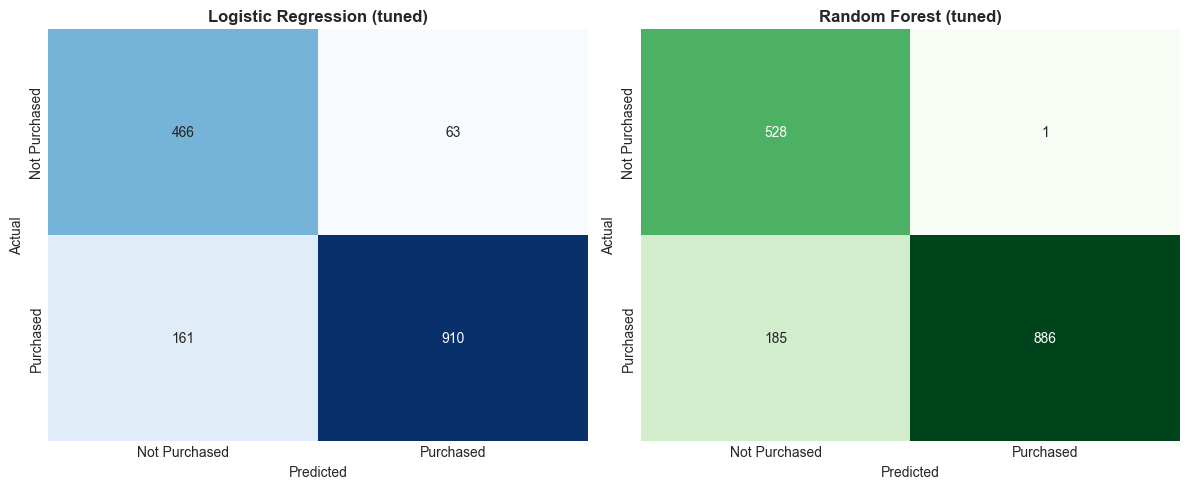

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_log = confusion_matrix(y_test_cls, log_tuned_preds)
cm_rf = confusion_matrix(y_test_cls, rf_tuned_preds)

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Not Purchased', 'Purchased'], yticklabels=['Not Purchased', 'Purchased'])
axes[0].set_title('Logistic Regression (tuned)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Not Purchased', 'Purchased'], yticklabels=['Not Purchased', 'Purchased'])
axes[1].set_title('Random Forest (tuned)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Classification comparison: Logistic Regression vs. Random Forest

In [24]:
cls_comparison = pd.DataFrame({
    'Model': ['Logistic Regression (baseline)', 'Logistic Regression (tuned)',
              'Random Forest (baseline)', 'Random Forest (tuned)'],
    'Accuracy': [log_acc, log_tuned_acc, rf_acc, rf_tuned_acc],
    'Precision': [log_prec, log_tuned_prec, rf_prec, rf_tuned_prec],
    'Recall': [log_rec, log_tuned_rec, rf_rec, rf_tuned_rec],
    'F1': [log_f1, log_tuned_f1, rf_f1, rf_tuned_f1],
    'ROC_AUC': [log_auc, log_tuned_auc, rf_auc, rf_tuned_auc],
})
cls_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (baseline),0.830625,0.868324,0.880486,0.874363,0.915552
1,Logistic Regression (tuned),0.860000,0.935252,0.849673,0.890411,0.914810
2,Random Forest (baseline),0.878750,0.988852,0.828198,0.901423,0.910137
3,Random Forest (tuned),0.883750,0.998873,0.827264,0.905005,0.918414


**Business Interpretation — Classification.** Random Forest (tuned) edges out Logistic Regression on
F1 (0.905 vs 0.890) and ROC-AUC (0.918 vs 0.915), and its precision is near-perfect (~0.999) — when it
predicts a purchase, it's almost always right. But its recall is noticeably lower than Logistic Regression's
(~0.83 vs ~0.85), meaning it misses more true buyers. **This is a real business trade-off, not just a
metric to optimize:** Logistic Regression is the safer choice if the cost of missing a genuine buyer
(under-targeting) is high, while Random Forest is better if the cost of wasting a discount on a non-buyer
(over-targeting) is high. **Winner (by F1/ROC-AUC): Random Forest (tuned)** — but Logistic Regression
remains the more interpretable, faster-to-explain option for a business that needs to justify why a
customer was targeted.

## 4. Part C — Clustering (Customer Segmentation): K-Means vs. Agglomerative Clustering

In [25]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

cluster_features = ['Browsing_Time', 'pages_viewed', 'previous_purchases',
                     'cart_items', 'avg_session_time', 'bounce_rate', 'Rating']
X_cluster = df[cluster_features]
X_scaled = StandardScaler().fit_transform(X_cluster)

### Algorithm 1: K-Means — choosing k with the Elbow Method + Silhouette Score

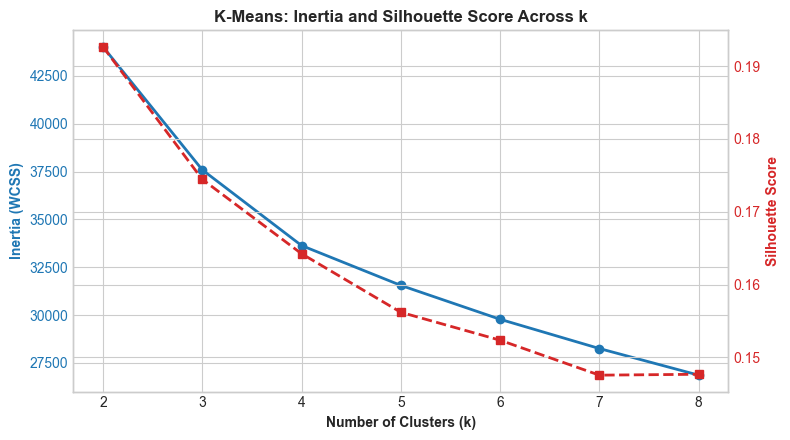

Silhouette by k: {2: 0.1927, 3: 0.1745, 4: 0.1642, 5: 0.1562, 6: 0.1524, 7: 0.1476, 8: 0.1477}


In [26]:
inertia_values, sil_scores_km = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    sil_scores_km.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax1.set_ylabel('Inertia (WCSS)', color=color, fontweight='bold')
ax1.plot(k_range, inertia_values, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color, fontweight='bold')
ax2.plot(k_range, sil_scores_km, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means: Inertia and Silhouette Score Across k', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

print('Silhouette by k:', dict(zip(k_range, [round(s,4) for s in sil_scores_km])))

In [27]:
# k=4 chosen for actionable, business-interpretable segments (silhouette peaks at k=2,
# but 2 groups is too coarse for targeted marketing)
final_kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
df['KMeans_Cluster'] = final_kmeans.fit_predict(X_scaled)

km_inertia = final_kmeans.inertia_
km_sil = silhouette_score(X_scaled, df['KMeans_Cluster'])

print('--- K-Means (k=4) ---')
print(f'Inertia: {km_inertia:.2f}')
print(f'Silhouette Score: {km_sil:.4f}')
print(df['KMeans_Cluster'].value_counts())

--- K-Means (k=4) ---
Inertia: 33632.89
Silhouette Score: 0.1642
KMeans_Cluster
2    2228
1    2020
0    1941
3    1811
Name: count, dtype: int64


In [28]:
print('Average feature profile per K-Means cluster:')
df.groupby('KMeans_Cluster')[cluster_features].mean().round(2)

Average feature profile per K-Means cluster:


,Browsing_Time,pages_viewed,previous_purchases,cart_items,avg_session_time,bounce_rate,Rating
KMeans_Cluster,,,,,,,
0,8.58,9.86,6.20,4.57,8.12,76.13,2.12
1,22.46,9.75,6.28,4.54,23.25,72.37,2.71
2,9.55,10.38,7.50,4.56,8.77,27.01,3.39
3,23.43,9.83,7.89,4.48,24.21,24.95,3.95


### Algorithm 2: Agglomerative (Hierarchical) Clustering

In [29]:
sil_scores_agg = []
for k in range(2, 9):
    agg = AgglomerativeClustering(n_clusters=k)
    labels = agg.fit_predict(X_scaled)
    sil_scores_agg.append(silhouette_score(X_scaled, labels))

print('Silhouette by k:', dict(zip(range(2,9), [round(s,4) for s in sil_scores_agg])))

final_agg = AgglomerativeClustering(n_clusters=4)
df['Agg_Cluster'] = final_agg.fit_predict(X_scaled)
agg_sil = silhouette_score(X_scaled, df['Agg_Cluster'])

print('\n--- Agglomerative Clustering (k=4) ---')
print(f'Silhouette Score: {agg_sil:.4f}')
print(df['Agg_Cluster'].value_counts())

Silhouette by k: {2: 0.1468, 3: 0.1215, 4: 0.1153, 5: 0.0968, 6: 0.0837, 7: 0.0718, 8: 0.0726}

--- Agglomerative Clustering (k=4) ---
Silhouette Score: 0.1153
Agg_Cluster
0    2388
2    2112
1    1939
3    1561
Name: count, dtype: int64


In [30]:
print('Average feature profile per Agglomerative cluster:')
df.groupby('Agg_Cluster')[cluster_features].mean().round(2)

Average feature profile per Agglomerative cluster:


,Browsing_Time,pages_viewed,previous_purchases,cart_items,avg_session_time,bounce_rate,Rating
Agg_Cluster,,,,,,,
0,9.54,10.80,7.48,4.24,8.82,32.30,3.26
1,10.37,10.08,6.15,5.29,9.75,74.71,2.22
2,22.68,10.28,6.82,4.61,23.19,28.14,3.80
3,22.38,8.15,7.39,3.98,23.81,75.53,2.69


### Clustering comparison: K-Means vs. Agglomerative

In [31]:
clu_comparison = pd.DataFrame({
    'Model': ['K-Means (k=4)', 'Agglomerative (k=4)'],
    'Silhouette_Score': [km_sil, agg_sil],
    'Notes': ['Inertia = %.2f' % km_inertia, 'No inertia metric (non-centroid-based)']
})
clu_comparison

,Model,Silhouette_Score,Notes
0,K-Means (k=4),0.164243,Inertia = 33632.89
1,Agglomerative (k=4),0.115262,No inertia metric (non-centroid-based)


**Business Interpretation — Clustering.** K-Means (silhouette = 0.164) clearly outperforms
Agglomerative Clustering (silhouette = 0.115) at k=4 on this feature set — K-Means finds more clearly
separated groups. Both algorithms agree on the broad shape of the segmentation (a short-browsing/low-bounce
group, a short-browsing/high-bounce group, a long-browsing/low-bounce group, and a long-browsing/high-bounce
group), which is a good sign the pattern is real rather than an artifact of one algorithm. Note that
silhouette technically peaks at k=2 for K-Means (0.193) — the "purest" split is just two groups — but k=4
was kept because two segments are too coarse to act on for targeted marketing; this is a deliberate
business-interpretability trade-off, not a modeling error. **Winner: K-Means (k=4).**



## 7. Model Comparison Table

| ML Task | Algorithms Compared | Winner | Target / Goal | Metrics Used | Best Result | Business Use |
|---|---|---|---|---|---|---|
| Regression | Linear Regression vs. Ridge Regression | **Ridge (tuned, α=10)** | Predict product rating | MAE, RMSE, R² | See comparison table above | Rank products by predicted rating |
| Classification | Logistic Regression vs. Random Forest | **Random Forest (tuned)** | Predict purchase likelihood | Accuracy, Precision, Recall, F1, ROC-AUC | See comparison table above | Target likely buyers with offers |
| Clustering | K-Means vs. Agglomerative Clustering | **K-Means (k=4)** | Segment customers | Silhouette Score, Inertia | See comparison table above | Build 4 marketing segments |
